In [2]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.3 MB 9.0 MB/s eta 0:00:01
   ------------- -------------------------- 2.9/8.3 MB 7.7 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.3 MB 7.2 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.3 MB 6.4 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.3 MB 5.4 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.3 MB 5.4 MB/s eta 0:00:01
   --------------------------- ------------ 5.8/8.3 MB 4.7 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.3 MB 3.8 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.3 MB 3.7 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 3.7 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 3.7 MB/s  0:00:02

   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ------------------------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from lab_utils_common import dlc
np.set_printoptions(precision=2)
plt.style.use('./deeplearning.mplstyle')


1. Gradient Descent


1.1 Load the data set


In [28]:
import numpy as np

X_train = np.array([
    [2104, 5, 1, 45],
    [1416, 3, 2, 40],
    [1534, 3, 2, 30],
    [852,  2, 1, 36],
    [1940, 4, 2, 15]
])

y_train = np.array([460, 232, 315, 178, 380])

X_features = ['size(sqft)', 'bedrooms', 'floors', 'age']

1.2 Scale/normalize the training data

In [24]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_train)
print(f"Peak to Peak range by column in Raw        X:{np.ptp(X_train,axis=0)}")   
print(f"Peak to Peak range by column in Normalized X:{np.ptp(X_norm,axis=0)}")

Peak to Peak range by column in Raw        X:[3626    3    2   42]
Peak to Peak range by column in Normalized X:[4.08 3.15 2.77 3.07]


1.3Create and fit the regression model

In [25]:
sgdr = SGDRegressor(max_iter=1000)
sgdr.fit(X_norm, y_train)
print(sgdr)
print(f"number of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}")

SGDRegressor()
number of iterations completed: 1000, number of weight updates: 12001.0


c:\Users\Vashnavi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1620: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


1.4 View parameters

In [26]:
b_norm = sgdr.intercept_
w_norm = sgdr.coef_
print(f"model parameters:                   w: {w_norm}, b:{b_norm}")
print( "model parameters from previous lab: w: [110.56 -21.27 -32.71 -37.97], b: 363.16")

model parameters:                   w: [127.24  44.43  13.22  -7.02], b:[374.6]
model parameters from previous lab: w: [110.56 -21.27 -32.71 -37.97], b: 363.16


1.5 Make predictions

In [18]:
# make a prediction using sgdr.predict()
y_pred_sgd = sgdr.predict(X_norm)
# make a prediction using w,b. 
y_pred = np.dot(X_norm, w_norm) + b_norm  
print(f"prediction using np.dot() and sgdr.predict match: {(y_pred == y_pred_sgd).all()}")

print(f"Prediction on training set:\n{y_pred[:4]}" )
print(f"Target values \n{y_train[:4]}")

prediction using np.dot() and sgdr.predict match: True
Prediction on training set:
[456.53 254.75 280.59 180.43]
Target values 
[460 232 315 178]


1.6 Plot Results

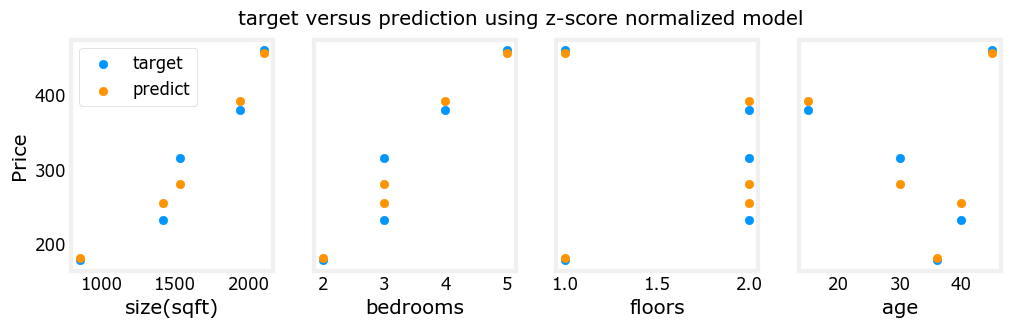

In [29]:
# plot predictions and targets vs original features    
fig,ax=plt.subplots(1,4,figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i],y_train, label = 'target')
    ax[i].set_xlabel(X_features[i])
    ax[i].scatter(X_train[:,i],y_pred,color=dlc["dlorange"], label = 'predict')
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("target versus prediction using z-score normalized model")
plt.show()

Example to test the model

In [30]:
# New house: [size, bedrooms, floors, age]
new_house = np.array([[1800, 3, 2, 20]])

# Normalize using the SAME scaler used for training
new_house_norm = scaler.transform(new_house)

# Predict price
predicted_price = sgdr.predict(new_house_norm)

print(f"Predicted house price: {predicted_price[0]:.2f}")

Predicted house price: 338.28
